## `MessageState` - 대화형 앱의 상태 관리

<br>

### 메시지 기반 상호작용의 특성
- **대부분의 LLM 프로바이더(OpenAI, Anthropic, Google 등)는 채팅 인터페이스를 통해 상호작용 $\rightarrow$ 대화 기록을 메시지 리스트로 관리해야 함을 의미**

- LLM이 기대하는 메시지 형식

```python
messages = [
    {"role": "user", "content": "안녕하세요"},
    {"role": "assistant", "content": "안녕하세요! 무엇을 도와드릴까요?"},
    {"role": "user", "content": "날씨가 어때요?"}
]

```

<br>

#### 메시지 관리의 핵심 과제
- **누적 vs 덮어쓰기**: 새 메시지는 기존 메시지에 추가되어야 함
- **메시지 수정**: Human-in-the-Loop에서 기존 메시지를 수정해야 할 때
- **중복 방지**: 같은 ID의 메시지가 중복 추가되면 안 됨
- **타입 일관성**: 다양한 메시지 타입(`HumanMessage`, `AIMessage` 등)을 일관되게 처리

<br>

### `add_messages` 리듀서

<br>

#### `operator.add`의 한계
- **단순히 `operator.add`를 사용하면 메시지가 무조건 추가됨**

In [1]:
from operator import add
from typing import Annotated
from typing_extensions import TypedDict

In [2]:
class SimpleState(TypedDict):
    messages: Annotated[list, add]  # 단순 리스트 연결

<br>

- 문제 상황: 메시지 수정이 필요한 경우

In [3]:
state = {"messages": [
    {"id": "msg1", "content": "안녕하세요"}
]}

In [4]:
update = {"messages": [
    {"id": "msg1", "content": "안녕하세요! (수정됨)"}
]}

- **결과: 중복 발생**

```python
{"messages": [
    {"id": "msg1", "content": "안녕하세요"},
    {"id": "msg1", "content": "안녕하세요! (수정됨)"}  # 중복!
]}
```

<br>

#### `add_messages`의 처리
- **`add_messages` 리듀서는 메시지 ID를 추적하여 중복을 방지**

In [5]:
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict

In [6]:
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]

In [7]:
# 동일한 상황에서 add_messages 사용
# 기존 상태
state = {"messages": [
    {"id": "msg1", "content": "안녕하세요"}
]}

# 수정된 메시지
update = {"messages": [
    {"id": "msg1", "content": "안녕하세요! (수정됨)"}
]}

- **결과: ID가 같으면 업데이트**

```python
{"messages": [
    {"id": "msg1", "content": "안녕하세요! (수정됨)"}
]}
```

<br>

#### `add_messages`의 핵심 동작
- 새 메시지 (새 ID): 기존 리스트에 추가
- 기존 메시지 (같은 ID): 해당 메시지를 업데이트 (덮어쓰기)
- 자동 역직렬화: 딕셔너리 형태의 메시지를 LangChain 메시지 객체로 자동 변환

```python
from langchain_core.messages import HumanMessage, AIMessage

# 딕셔너리 형태로 전달해도
update = {"messages": [
    {"role": "user", "content": "안녕하세요"}
]}

# add_messages가 자동으로 HumanMessage로 변환
# state["messages"][-1] 는 HumanMessage 객체
```

<br>

### `MessagesState` 사용
- **`MessagesState`는 `messages` 필드와 `add_messages` 리듀서가 미리 정의된 상태 클래스**

In [8]:
from langgraph.graph import MessagesState

In [9]:
class MyState(MessagesState):
    pass  # messages 필드가 자동으로 포함됨

<br>

#### 필드 확장

In [10]:
from langgraph.graph import MessagesState
from typing import Optional

In [11]:
class ChatbotState(MessagesState):
    # MessagesState에서 messages 상속
    user_name: str                    # 사용자 이름
    language: str                     # 응답 언어
    context: Optional[list[str]]      # RAG 컨텍스트
    turn_count: int    

<br>

#### 간단한 챗봇 예제

In [12]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import HumanMessage, AIMessage

In [13]:
class ChatState(MessagesState):
    user_name: str

In [14]:
def greet_user(state: ChatState) -> dict:
    """사용자 인사 처리"""
    user_msg = state["messages"][-1]
    response = AIMessage(
        content=f"안녕하세요, {state['user_name']}님! 무엇을 도와드릴까요?"
    )
    return {"messages": [response]}

In [15]:
def process_question(state: ChatState) -> dict:
    """질문 처리"""
    user_msg = state["messages"][-1]
    response = AIMessage(
        content=f"'{user_msg.content}'에 대한 답변입니다."
    )
    return {"messages": [response]}

- 그래프 구성

In [16]:
graph = StateGraph(ChatState)
graph.add_node("greet", greet_user)
graph.add_node("answer", process_question)

graph.add_edge(START, "greet")
graph.add_edge("greet", "answer")
graph.add_edge("answer", END)

app = graph.compile()

- 실행

In [18]:
result = app.invoke({
    "messages": [HumanMessage(content="안녕하세요")],
    "user_name": "홍길동"
})

In [19]:
print(f"메시지 수: {len(result['messages'])}")
for msg in result["messages"]:
    role = "User" if isinstance(msg, HumanMessage) else "AI"
    print(f"{role}: {msg.content}")

메시지 수: 3
User: 안녕하세요
AI: 안녕하세요, 홍길동님! 무엇을 도와드릴까요?
AI: '안녕하세요, 홍길동님! 무엇을 도와드릴까요?'에 대한 답변입니다.


<br>

### 메시지 ID 관리
- **메시지 ID는 Human-in-the-Loop이나 메시지 수정에서 필수적**


In [20]:
from langchain_core.messages import HumanMessage, AIMessage

- ID가 있는 메시지


In [ ]:
msg_with_id = HumanMessage(
    content="안녕하세요",
    id="user_msg_001"  # 명시적 ID 지정
)

* ID 없이 생성하면 자동으로 UUID 할당

In [ ]:
msg_auto_id = HumanMessage(content="안녕하세요")
print(msg_auto_id.id)  # 예: "a1b2c3d4-..."

<br>

#### 메시지 업데이트 패턴

In [24]:
def edit_message_node(state: ChatState) -> dict:
    """특정 메시지를 수정하는 노드"""
    # 마지막 AI 메시지의 ID를 가져옴
    last_ai_msg = state["messages"][-1]

    # 같은 ID로 새 메시지를 보내면 업데이트됨
    edited_msg = AIMessage(
        content=last_ai_msg.content + " (검토 완료)",
        id=last_ai_msg.id  # 기존 ID 유지
    )

    return {"messages": [edited_msg]}

<br>

#### 메시지 삭제 패턴

In [25]:
from langgraph.graph.message import RemoveMessage

In [26]:
def cleanup_messages(state: ChatState) -> dict:
    """오래된 메시지 삭제"""
    # 처음 2개 메시지만 유지하고 나머지 삭제
    messages_to_remove = state["messages"][2:]

    return {
        "messages": [
            RemoveMessage(id=msg.id) 
            for msg in messages_to_remove
        ]
    }

<br>

#### 메시지 필터링
- 특정 조건의 메시지만 처리하는 패턴


In [27]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

In [28]:
def get_recent_exchanges(state: ChatState, n: int = 3) -> list:
    """최근 n개의 사용자-AI 대화쌍 추출"""
    messages = state["messages"]

    # 시스템 메시지 제외
    exchanges = [
        msg for msg in messages 
        if not isinstance(msg, SystemMessage)
    ]

    # 최근 n개 쌍 (2*n개 메시지)
    return exchanges[-(n*2):]

<br>

#### 메시지 요약 패턴
- 대화가 길어지면 이전 내용을 요약하여 토큰을 절약

In [29]:
from langchain_core.messages import SystemMessage

In [30]:
class SummarizableState(MessagesState):
    summary: str  # 이전 대화 요약

In [31]:
def maybe_summarize(state: SummarizableState) -> dict:
    """메시지가 많아지면 요약"""
    if len(state["messages"]) <= 10:
        return {}  # 변경 없음

    # 처음 8개 메시지를 요약 (실제로는 LLM 호출)
    old_messages = state["messages"][:8]
    summary_text = "이전 대화 요약: ..."

    # 요약을 저장하고 오래된 메시지 삭제
    return {
        "summary": summary_text,
        "messages": [
            RemoveMessage(id=msg.id) 
            for msg in old_messages
        ]
    }

<br>

### Private State - 노드 간 비공개 데이터
- **노드 간에 중간 로직에 필요하지만 그래프의 메인 스키마에 포함될 필요가 없는 정보를 교환해야 할 때가 존재**
  
  $\rightarrow$ **이런 비공개 데이터는 그래프 전체의 입출력과 무관하며 특정 노드 간에만 공유되어야 함**

<br>

- **Private State는 특정 노드들 사이에서만 공유되는 상태이며, 그래프의 입력/출력 스키마에 포함되지 않으며, 내부적인 중간 처리에만 사용**
  - 중간 처리 데이터: 최종 결과에는 포함되지 않지만 처리 과정에서 필요한 데이터
  - 노드 간 내부 통신: 특정 노드들만 알아야 하는 정보
  - 상태 분리: 공개 상태와 내부 상태를 명확하게 구분

<br>

#### 기본 구현
- **노드는 초기화 시 StateGraph에 전달되지 않았더라도 추가 상태 채널을 선언할 수 있음**
- 해당 상태 스키마 정의가 존재하기만 하면 됨

<br>


In [32]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

- 공개 상태 - 그래프 입출력에 사용


In [33]:
class PublicState(TypedDict):
    user_query: str
    final_answer: str

- 비공개 상태 - 내부 노드 간 통신용

In [34]:
class PrivateState(TypedDict):
    intermediate_result: str
    processing_metadata: dict

- 노드 함수 정의

In [37]:
def node_1(state: PublicState) -> PrivateState:
    """첫 번째 노드: 공개 상태를 읽고 비공개 상태로 출력"""
    query = state["user_query"]

    # 중간 처리 결과를 비공개 상태로 저장
    return {
        "intermediate_result": f"처리됨: {query}",
        "processing_metadata": {"step": 1, "status": "preprocessed"}
    }

In [38]:
def node_2(state: PrivateState) -> PublicState:
    """두 번째 노드: 비공개 상태를 읽고 공개 상태로 출력"""
    intermediate = state["intermediate_result"]
    metadata = state["processing_metadata"]

    # 비공개 상태를 처리하여 최종 공개 결과 생성
    return {
        "final_answer": f"완료! {intermediate} (단계: {metadata['step']})"
    }

In [39]:
def node_3(state: PublicState) -> dict:
    """세 번째 노드: 공개 상태만 접근 (비공개 상태 접근 불가)"""
    return {"final_answer": state["final_answer"] + " [검증됨]"}

<br>

- 그래프 구성

In [40]:
builder = StateGraph(PublicState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

graph = builder.compile()

In [44]:
from visualize_graph import visualize_graph

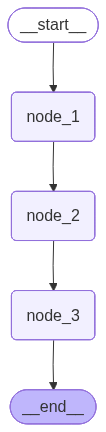

In [45]:
visualize_graph(graph)

In [41]:
result = graph.invoke({"user_query": "Python이란?"})
print(result)

{'user_query': 'Python이란?', 'final_answer': '완료! 처리됨: Python이란? (단계: 1) [검증됨]'}


<br>

### 입출력 스키마 분리
- 그래프의 입력과 출력을 명시적으로 다른 스키마로 정의
- **내부 상태가 복잡하지만 외부 인터페이스는 단순하게 유지하고 싶을 때 유용**

<br>



In [46]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

- 입력 스키마

In [48]:
class InputState(TypedDict):
    question: str

- 출력 스키마

In [49]:
class OutputState(TypedDict):
    answer: str

- 내부 전체 상태 (입출력 + 비공개)


In [50]:
class OverallState(TypedDict):
    question: str           # 입력에서 옴
    answer: str             # 출력으로 나감
    intermediate_data: str  # 내부용
    processing_steps: list  # 내부용

- 노드 함수 정의

In [58]:
def analyze_node(state: InputState) -> dict:
    """입력을 분석하고 중간 데이터 생성"""
    return {
        "intermediate_data": f"분석됨: {state['question']}",
        "processing_steps": ["analyze"]
    }

In [59]:
def process_node(state: OverallState) -> dict:
    """중간 데이터를 처리"""
    steps = state["processing_steps"] + ["process"]
    return {
        "intermediate_data": state["intermediate_data"] + " -> 처리됨",
        "processing_steps": steps
    }

In [60]:
def answer_node(state: OverallState) -> OutputState:
    """최종 답변 생성"""
    return {
        "answer": f"답변: {state['intermediate_data']} (단계: {len(state['processing_steps'])})"
    }

In [61]:
builder = StateGraph(
    OverallState,
    input_schema=InputState,
    output_schema=OutputState
)

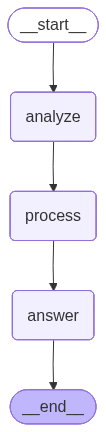

In [62]:
builder.add_node("analyze", analyze_node)
builder.add_node("process", process_node)
builder.add_node("answer", answer_node)

builder.add_edge(START, "analyze")
builder.add_edge("analyze", "process")
builder.add_edge("process", "answer")
builder.add_edge("answer", END)

graph = builder.compile()
visualize_graph(graph)

In [63]:
result = graph.invoke({"question": "LangGraph란?"})
print(result)

{'answer': '답변: 분석됨: LangGraph란? -> 처리됨 (단계: 2)'}


<br>

<hr>